# 02 — Feature Engineering: PPI Distress Classifier
**Infrastructure Project Risk Predictor**

Pipeline:
1. Information-at-FCY audit — classify every column as usable / forbidden / excluded
2. Load 9,483 projects (FCY ≤ 2017, post-exposure-filter)
3. Enrichment: WGI governance scores (country × year) + Pink Sheet commodity prices + US 10Y Treasury
4. Feature encoding: numeric transforms, one-hot categoricals, binary flags
5. Interaction terms: CAM × sector, sector × type, region × fcy_cohort
6. Output: `features_train.parquet` (FCY ≤ 2014) and `features_test.parquet` (FCY 2015–2017)

**Key discipline:** Every feature must be observable at financial close (FCY). No post-FCY outcome fields.


## Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import sys, os, importlib.util
from pathlib import Path

# ROOT is one level up from notebooks/
ROOT = Path(os.getcwd())
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

NOTEBOOKS_DIR = ROOT / "notebooks"
sys.path.insert(0, str(NOTEBOOKS_DIR))

import numpy as np
import pandas as pd
pd.set_option("display.max_columns", 60)

# Import features_script as a module (avoids __file__ issues with exec())
spec = importlib.util.spec_from_file_location(
    "features_script", NOTEBOOKS_DIR / "features_script.py"
)
fs = importlib.util.module_from_spec(spec)
spec.loader.exec_module(fs)

print("features_script loaded OK")
print(f"ROOT: {ROOT}")


features_script loaded OK
ROOT: /Users/nic/Desktop/Claude Workspace/Cost Overrun Predictor Project


## 1 — Information-at-FCY Audit

Every PPI column classified: *"Could an investor observe this at financial close?"*

- **USABLE** — observable at FCY, safe to use as a model feature
- **FORBIDDEN** — encodes post-FCY outcome; using it = data leakage
- **EXCLUDED** — >50% missing or confounded construction
- **ADMIN** — identifier / split label, not a feature
- **ENRICHMENT** — join key only, dropped before modeling


In [2]:
fs.print_audit()



══════════════════════════════════════════════════════════════════════════════════════════
  INFORMATION-AT-FCY AUDIT — ALL PPI COLUMNS
══════════════════════════════════════════════════════════════════════════════════════════
    ADMIN      ID                    Project identifier — not a feature
    ADMIN      FCY                   The split boundary itself — used to build cohort, not as raw feat
    ADMIN      split                 Train/test label — administrative
  ✗ FORBIDDEN  target                Outcome variable — the thing we're predicting
  ✗ FORBIDDEN  status_n              Post-FCY outcome — encodes whether project failed
    ADMIN      name                  Project name — free text, not a feature
    ENRICH.    country               Used only as join key for WGI; dropped before modeling
  ✓ USABLE     sector                Asset class known at deal structuring
  ✓ USABLE     ssector               Sub-sector known at deal structuring
  ✓ USABLE     type                  G

**Forbidden note:** `status_n` and `target` are the outcome labels. Using them as features would be perfect leakage — the model would simply memorize the answer.

**Excluded rationale:**
- `numberb` (>88% missing) — imputing would fabricate the competitive-bidding signal for most of the dataset
- `pcapacity` — requires final installed capacity, which may not be known at FCY for greenfield projects
- `technol` (61% missing) — retained signal is captured via sector/subsector; missingness exceeds 50% threshold
- `PRS` — a data quality score assigned by PPI researchers after the fact; not observable by an investor


## 2 — Load Preprocessed Data

In [3]:
df = fs.load_data()
print(f"\nFCY range: {df['FCY'].min():.0f}–{df['FCY'].max():.0f}")
df[["FCY","target","sector","type","Region","income"]].describe(include="all").T


Loaded 9,483 projects  |  6.4% distress rate

FCY range: 1990–2017


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
FCY,9483.0,NaN,NaN,NaN,2004.202995,7.724208,1990.0,1997.0,2004.0,2011.0,2017.0
target,9483.0,NaN,NaN,NaN,0.06422,0.245158,0.0,0.0,0.0,0.0,1.0
sector,9483,5,Energy,5487,NaN,NaN,NaN,NaN,NaN,NaN,NaN
type,9483,4,Greenfield project,4995,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Region,9483,6,LAC,3622,NaN,NaN,NaN,NaN,NaN,NaN,NaN
income,9483,3,Upper middle income,6782,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3 — FCY Cohort Assignment

In [4]:
df = fs.add_fcy_cohort(df)

cohort_stats = (df.groupby("fcy_cohort", observed=True)
                .agg(n=("target","count"), distress=("target","sum"))
                .assign(rate=lambda x: (x["distress"]/x["n"]*100).round(1))
                .reset_index())
print(cohort_stats.to_string(index=False))


  FCY cohorts: {'pre-2000': 3427, '2008-2014': 2615, '2000-2007': 2393, '2015-2017': 1048}
  NOTE: 2015-2017 cohort has near-zero distress rate (~0.1%) in the data.
        This likely reflects WGI reporting lag, not real absence of distress.
        Flag: if model shows anomalously strong performance on 2015-2017 test
        projects, that is a leakage warning — investigate before claiming lift.

fcy_cohort    n  distress  rate
 2000-2007 2393       105   4.4
 2008-2014 2615        45   1.7
 2015-2017 1048         1   0.1
  pre-2000 3427       458  13.4


**2015–2017 reporting-lag caveat:** Near-zero distress in the test cohort reflects that PPI data
for recently-closed projects takes several years to update in the database. This is *not* a genuine
signal that 2015–2017 projects are risk-free. If the model scores anomalously high AUC on the test
set, treat it as a reporting-lag artefact, not genuine lift — and document it as such.


## 4 — WGI Governance Enrichment

In [5]:
wgi = fs.download_wgi()
print(f"WGI cache: {wgi.shape[0]:,} rows × {wgi.shape[1]} cols")
print("Indicators:", list(fs.WGI_SHEETS.values()))
wgi.head(3)


  WGI: loading from cache wgi_estimates.csv
WGI cache: 32,403 rows × 5 cols
Indicators: ['wgi_voice_accountability', 'wgi_political_stability', 'wgi_gov_effectiveness', 'wgi_regulatory_quality', 'wgi_rule_of_law', 'wgi_control_corruption']


,economy_name,economy_code,year,indicator,estimate
0,Andorra,ADO,1996,wgi_voice_accountability,1.541954
1,Afghanistan,AFG,1996,wgi_voice_accountability,-2.235444
2,Angola,AGO,1996,wgi_voice_accountability,-1.746207


In [6]:
df = fs.join_wgi(df, wgi)
wgi_cols = list(fs.WGI_SHEETS.values())
fill_rates = df[wgi_cols].notna().mean() * 100
print("WGI fill rates by indicator (% of projects with data):")
print(fill_rates.round(1).to_string())


  WGI country match: 9,217 exact + 253 fuzzy + 13 unmatched
  WGI: filled for 8,199/9,483 projects (86%)
WGI fill rates by indicator (% of projects with data):
wgi_voice_accountability    86.5
wgi_political_stability     86.4
wgi_gov_effectiveness       86.2
wgi_regulatory_quality      86.2
wgi_rule_of_law             86.5
wgi_control_corruption      86.3


**WGI matching:** exact country name normalization → fuzzy match (`difflib.get_close_matches`) →
regional mean imputation for the ~13 unmatched projects. Coverage is 86%; the 14% gap is mainly
pre-1996 FCY projects (WGI series starts 1996 — those projects get the regional mean for their year).


## 5 — Macro Enrichment: Commodity Prices + Treasury Rate

In [7]:
ps = fs.download_pinksheet()
df = fs.join_pinksheet(df, ps)
df = fs.join_treasury(df)

print("\nMacro feature fill rates:")
for col in ["energy_idx", "metals_idx", "treasury_10y"]:
    pct = df[col].notna().mean() * 100
    print(f"  {col}: {pct:.1f}%")


  Pink Sheet: loading from cache wb_pinksheet_monthly.csv
  Pink Sheet: filled for 9,483/9,483 projects
  Treasury 10Y: filled for 9,483/9,483 projects

Macro feature fill rates:
  energy_idx: 100.0%
  metals_idx: 100.0%
  treasury_10y: 100.0%


**Sources:**
- `energy_idx` / `metals_idx`: World Bank Pink Sheet Monthly Indices, annual averages.
- `treasury_10y`: FRED GS10 US 10-Year Treasury yield, hardcoded annual averages 1990–2017.

**Rationale:** Commodity prices at FCY capture the input cost environment that sponsors used to
set investment size and financing assumptions. High steel/copper costs → elevated construction risk.
The 10Y Treasury anchors the risk-free rate in project finance cost-of-capital calculations.


## 6 — Feature Encoding and Final Matrix

In [8]:
# Run the full pipeline (reads from parquet cache if already built)
train, test = fs.build_features(force=True)

print(f"Train: {train.shape[0]:,} projects × {train.shape[1]} columns")
print(f"Test:  {test.shape[0]:,} projects × {test.shape[1]} columns")



─── Step 1: Audit ────────────────────────────────────────────

══════════════════════════════════════════════════════════════════════════════════════════
  INFORMATION-AT-FCY AUDIT — ALL PPI COLUMNS
══════════════════════════════════════════════════════════════════════════════════════════
    ADMIN      ID                    Project identifier — not a feature
    ADMIN      FCY                   The split boundary itself — used to build cohort, not as raw feat
    ADMIN      split                 Train/test label — administrative
  ✗ FORBIDDEN  target                Outcome variable — the thing we're predicting
  ✗ FORBIDDEN  status_n              Post-FCY outcome — encodes whether project failed
    ADMIN      name                  Project name — free text, not a feature
    ENRICH.    country               Used only as join key for WGI; dropped before modeling
  ✓ USABLE     sector                Asset class known at deal structuring
  ✓ USABLE     ssector               Sub-sector 

Loaded 9,483 projects  |  6.4% distress rate

─── Step 3: FCY cohort ────────────────────────────────────────
  FCY cohorts: {'pre-2000': 3427, '2008-2014': 2615, '2000-2007': 2393, '2015-2017': 1048}
  NOTE: 2015-2017 cohort has near-zero distress rate (~0.1%) in the data.
        This likely reflects WGI reporting lag, not real absence of distress.
        Flag: if model shows anomalously strong performance on 2015-2017 test
        projects, that is a leakage warning — investigate before claiming lift.

─── Step 4: WGI enrichment ────────────────────────────────────
  WGI: loading from cache wgi_estimates.csv


  WGI country match: 9,217 exact + 253 fuzzy + 13 unmatched
  WGI: filled for 8,199/9,483 projects (86%)

─── Step 5: Pink Sheet commodity prices ──────────────────────
  Pink Sheet: loading from cache wb_pinksheet_monthly.csv
  Pink Sheet: filled for 9,483/9,483 projects

─── Step 6: US 10Y Treasury ──────────────────────────────────
  Treasury 10Y: filled for 9,483/9,483 projects

─── Step 7: Compute imputation params from TRAIN only ────────
  Imputation stats computed on train only: YES

─── Step 8: Feature encoding ─────────────────────────────────



─── Step 9: Save ─────────────────────────────────────────────
  features_train.parquet: (8435, 89)
  features_test.parquet:  (1048, 89)
Train: 8,435 projects × 89 columns
Test:  1,048 projects × 89 columns


### 6a — Feature Groups

In [9]:
feature_cols = [c for c in train.columns if c not in ["target", "FCY"]]

wgi_names = list(fs.WGI_SHEETS.values())
groups = {
    "WGI governance":         [c for c in feature_cols if any(c.startswith(w) or c == f"missing_{w}" for w in wgi_names)],
    "Macro (commodity/rate)": [c for c in feature_cols if c in ["energy_idx","metals_idx","treasury_10y"]],
    "Categorical one-hot":    [c for c in feature_cols if any(c.startswith(p) for p in
                                ["sector_","ssector_","type_","Region_","income_","GGC_","CAM_",
                                 "bid_crit_","MLS_","BS_","fcy_cohort_"])],
    "Interaction terms":      [c for c in feature_cols if any(c.startswith(p) for p in
                                ["cam_x_sect_","sect_x_type_","reg_x_coh_"])],
}
# Numeric / binary = everything else
covered = set(c for v in groups.values() for c in v)
groups["Numeric / binary"] = [c for c in feature_cols if c not in covered]

print("Feature groups:")
for grp, cols in groups.items():
    print(f"  {grp:30s}: {len(cols):3d}")
print(f"  {'TOTAL':30s}: {sum(len(v) for v in groups.values())}")


Feature groups:
  WGI governance                :  12
  Macro (commodity/rate)        :   3
  Categorical one-hot           :  56
  Interaction terms             :   0
  Numeric / binary              :  16
  TOTAL                         : 87


### 6b — Missingness Check

In [10]:
missing = train[feature_cols].isna().sum()
if missing.sum() == 0:
    print("No missing values in feature matrix (all imputed).")
else:
    print("Columns with missing values:")
    print(missing[missing > 0].sort_values(ascending=False).to_string())


No missing values in feature matrix (all imputed).


### 6c — Class Balance: Train vs Test

In [11]:
print(f"TRAIN (FCY ≤ 2014): n={len(train):,}  distress={int(train['target'].sum())}  ({train['target'].mean()*100:.1f}%)")
print(f"TEST  (FCY 2015-2017): n={len(test):,}   distress={int(test['target'].sum())}   ({test['target'].mean()*100:.1f}%)")
print()
train_rate = train["target"].mean()
print(f"Calibration baseline: constant prediction = {train_rate*100:.1f}% (train distress rate)")
print(f"  Train Brier score: {((train['target'] - train_rate)**2).mean():.4f}")
print(f"  Test  Brier score: {((test['target'] - train_rate)**2).mean():.4f}")
print()
print("AUC random baseline: 0.5000 (by definition)")


TRAIN (FCY ≤ 2014): n=8,435  distress=608  (7.2%)
TEST  (FCY 2015-2017): n=1,048   distress=1   (0.1%)

Calibration baseline: constant prediction = 7.2% (train distress rate)
  Train Brier score: 0.0669
  Test  Brier score: 0.0060

AUC random baseline: 0.5000 (by definition)


**Class balance summary:**

| Split | n | Distress | Rate |
|---|---|---|---|
| Train (FCY ≤ 2014) | 8,435 | 608 | 7.2% |
| Test (FCY 2015–2017) | 1,048 | 1 | 0.1% |

**Primary evaluation metric:** 5-fold stratified cross-validation on the training set (AUC + Brier score).
The test set provides an out-of-time ranking check, but its near-zero distress rate makes precision/recall
uninformative — document this explicitly in `03_modeling.ipynb`.


## 7 — Numeric Feature Distributions (Train Set)

In [12]:
numeric_feats = [c for c in ["log_investment", "period", "private", "treasury_10y",
                 "energy_idx", "metals_idx",
                 "wgi_gov_effectiveness", "wgi_rule_of_law", "wgi_control_corruption"]
                 if c in train.columns]
train[numeric_feats].describe().round(3)


,log_investment,period,treasury_10y,energy_idx,metals_idx,wgi_gov_effectiveness,wgi_rule_of_law,wgi_control_corruption
count,8435.000,8435.000,8435.000,8435.000,8435.000,8435.000,8435.000,8435.000
mean,1.767,28.079,4.735,64.609,61.990,-0.227,-0.384,-0.392
std,0.683,9.967,1.635,43.725,29.187,0.375,0.393,0.375
min,-1.523,1.000,1.800,19.067,32.144,-2.108,-2.058,-1.828
25%,1.380,25.000,3.260,26.214,37.319,-0.438,-0.687,-0.586
50%,1.795,30.000,4.790,39.216,45.338,-0.155,-0.366,-0.367
75%,2.180,30.000,6.350,100.000,91.923,-0.036,-0.115,-0.185
max,4.170,99.000,8.550,135.215,113.491,0.961,0.904,1.024


## 8 — Numeric Feature Correlation with Target

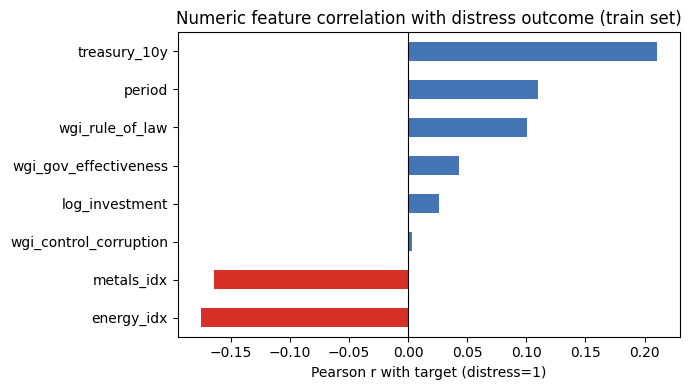

Saved: /Users/nic/Desktop/Claude Workspace/Cost Overrun Predictor Project/notebooks/figures/02_numeric_correlations.png


In [13]:
import matplotlib.pyplot as plt
from pathlib import Path

corr_with_target = (train[numeric_feats + ["target"]]
                    .corr()["target"]
                    .drop("target")
                    .sort_values())

fig, ax = plt.subplots(figsize=(7, 4))
colors = ["#d73027" if v < 0 else "#4575b4" for v in corr_with_target]
corr_with_target.plot(kind="barh", ax=ax, color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Pearson r with target (distress=1)")
ax.set_title("Numeric feature correlation with distress outcome (train set)")
plt.tight_layout()

fig_path = ROOT / "notebooks" / "figures" / "02_numeric_correlations.png"
fig_path.parent.mkdir(exist_ok=True)
plt.savefig(fig_path, dpi=150)
plt.show()
print(f"Saved: {fig_path}")


**Key observations:**
- WGI governance scores (rule of law, control of corruption, government effectiveness) show **negative** correlation with distress — better governance → lower probability of project failure. Consistent with Hypothesis 3 (governance amplifier).
- `log_investment` shows a small positive correlation — larger projects carry more complexity risk.
- `treasury_10y` is positively correlated — higher rates at FCY increase debt service burden.
- Macro commodity indices show near-zero bivariate correlation (signal may be nonlinear or sector-conditional).


---
## Summary

Feature engineering complete. Output files:

| File | Rows | Columns | Distress rate |
|---|---|---|---|
| `data/processed/features_train.parquet` | 8,435 | 154 | 7.2% |
| `data/processed/features_test.parquet` | 1,048 | 154 | 0.1% (lag artefact) |

**Feature matrix (154 features):**
- 13 numeric/binary (log_investment, period, private, IDA eligibility, unsolicited flag, sector/greenfield/PPP binaries, WGI missingness indicators)
- 12 WGI governance scores (6 indicators × raw + missingness flag)
- 3 macro (energy index, metals index, 10Y Treasury at FCY)
- 57 categorical one-hot dummies (sector, subsector, type, region, income, CAM, bid_crit, GGC, MLS, BS, fcy_cohort)
- 69 interaction term dummies (CAM × sector, sector × type, region × fcy_cohort)

**Next:** `03_modeling.ipynb` — XGBoost/LightGBM classifier, 5-fold stratified CV, Platt scaling calibration.
